In [1]:
import random
import torch

import clip
import utils
import data_utils
import similarity

import matplotlib
from matplotlib import pyplot as plt

/home/s4yadav/private/workspace/CLIP-dissect/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


## Settings

In [2]:
clip_name = 'ViT-B/16'
target_name = 'resnet50'
target_layer = 'layer4'
d_probe = 'imagenet_broden'
concept_set = 'data/20k.txt'
batch_size = 16
device = 'cuda'
pool_mode = 'avg'

save_dir = 'saved_activations'
similarity_fn = similarity.soft_wpmi

## Run CLIP-Dissect

In [3]:
utils.save_activations(clip_name = clip_name, target_name = target_name, target_layers = [target_layer], 
                       d_probe = d_probe, concept_set = concept_set, batch_size = batch_size, 
                       device = device, pool_mode=pool_mode, save_dir = save_dir)

In [4]:
save_names = utils.get_save_names(clip_name = clip_name, target_name = target_name,
                                  target_layer = target_layer, d_probe = d_probe,
                                  concept_set = concept_set, pool_mode=pool_mode,
                                  save_dir = save_dir)

target_save_name, clip_save_name, text_save_name = save_names

similarities, target_feats = utils.get_similarity_from_activations(target_save_name, clip_save_name, 
                                                             text_save_name, similarity_fn)

with open(concept_set, 'r') as f: 
    words = (f.read()).split('\n')

pil_data = data_utils.get_data(d_probe)

/home/s4yadav/private/workspace/CLIP-dissect/utils.py:153: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image_features = torch.load(clip_save_name, map_location='cpu').floa

torch.Size([2048, 20000])


## Visualize Results


 Layer:layer4 Neuron:1878
1st description: maize, sim:0.419
2nd description: corn, sim:0.407
3rd description: kernels, sim:0.334
5 most highly activating images in D_probe:


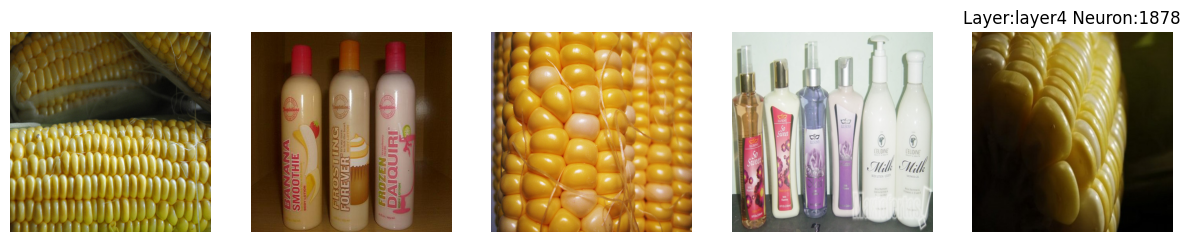


 Layer:layer4 Neuron:1490
1st description: mop, sim:0.266
2nd description: wool, sim:0.209
3rd description: fringe, sim:0.196
5 most highly activating images in D_probe:


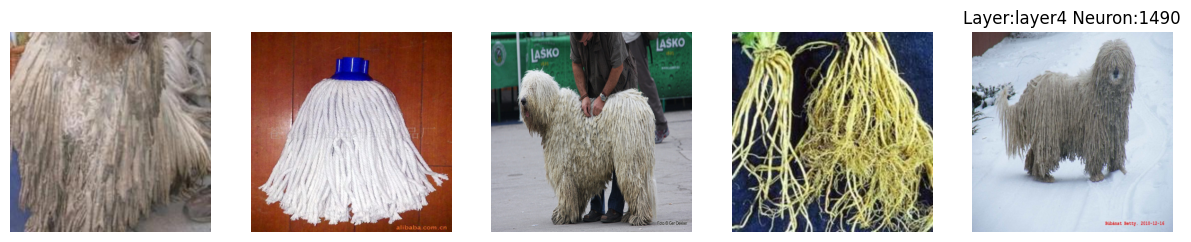


 Layer:layer4 Neuron:1998
1st description: buried, sim:0.175
2nd description: pudding, sim:0.169
3rd description: desserts, sim:0.154
5 most highly activating images in D_probe:


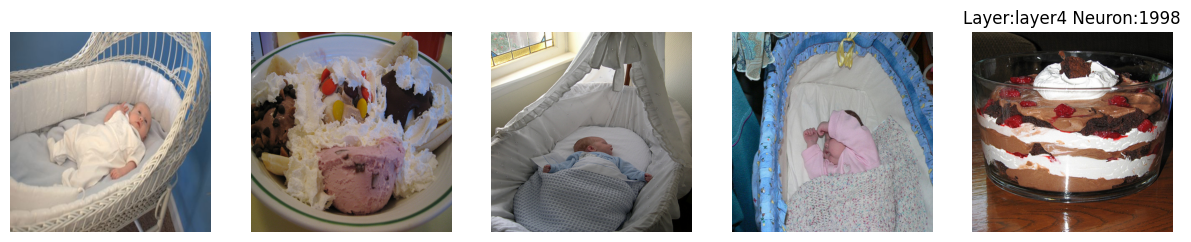


 Layer:layer4 Neuron:196
1st description: terrier, sim:0.270
2nd description: barking, sim:0.205
3rd description: maltese, sim:0.204
5 most highly activating images in D_probe:


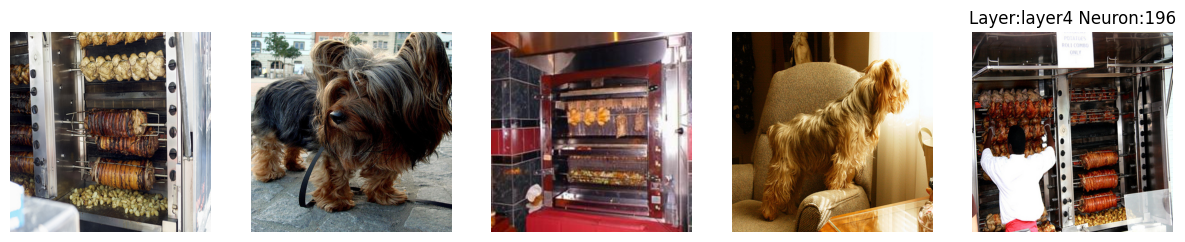


 Layer:layer4 Neuron:1526
1st description: crocodile, sim:0.235
2nd description: newsgator, sim:0.173
3rd description: predators, sim:0.143
5 most highly activating images in D_probe:


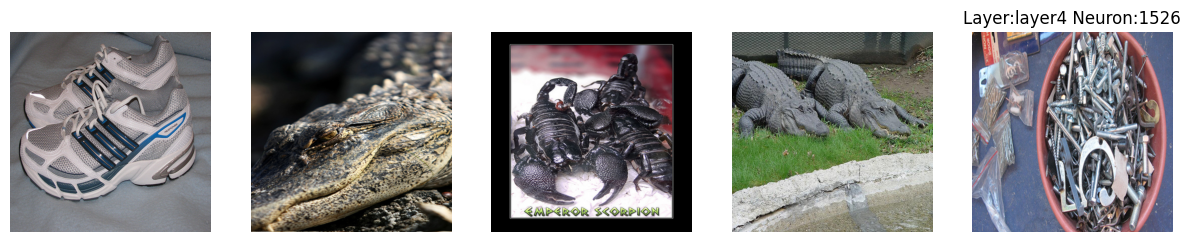


 Layer:layer4 Neuron:48
1st description: wicker, sim:0.335
2nd description: baskets, sim:0.247
3rd description: cradle, sim:0.207
5 most highly activating images in D_probe:


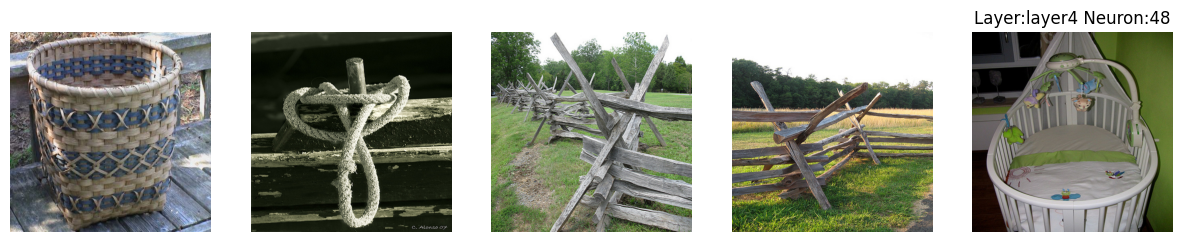


 Layer:layer4 Neuron:46
1st description: dog, sim:0.240
2nd description: dogs, sim:0.226
3rd description: puppy, sim:0.219
5 most highly activating images in D_probe:


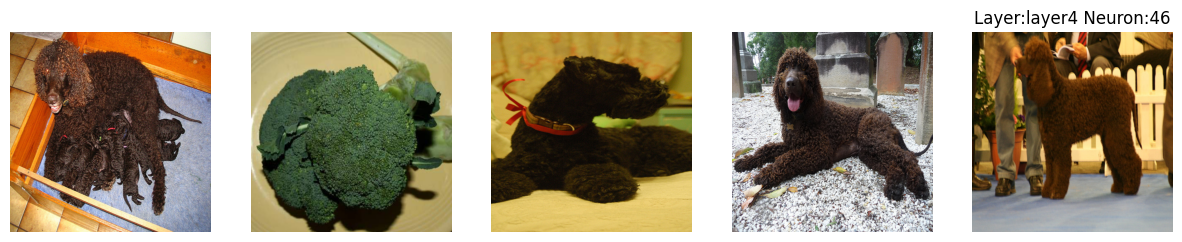


 Layer:layer4 Neuron:1635
1st description: closeouts, sim:0.152
2nd description: footwear, sim:0.149
3rd description: shoes, sim:0.142
5 most highly activating images in D_probe:


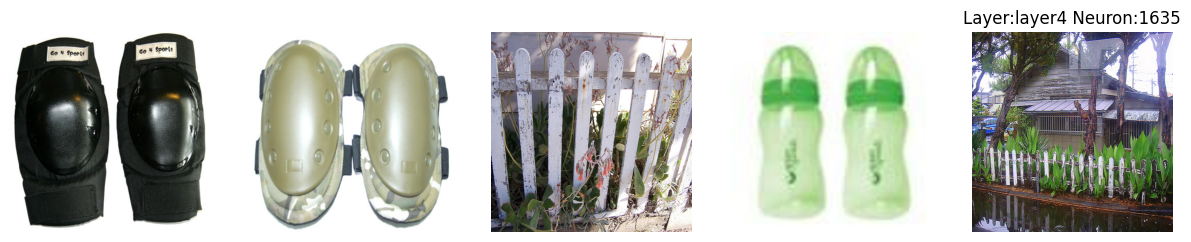


 Layer:layer4 Neuron:1206
1st description: boots, sim:0.326
2nd description: boot, sim:0.271
3rd description: sergeant, sim:0.253
5 most highly activating images in D_probe:


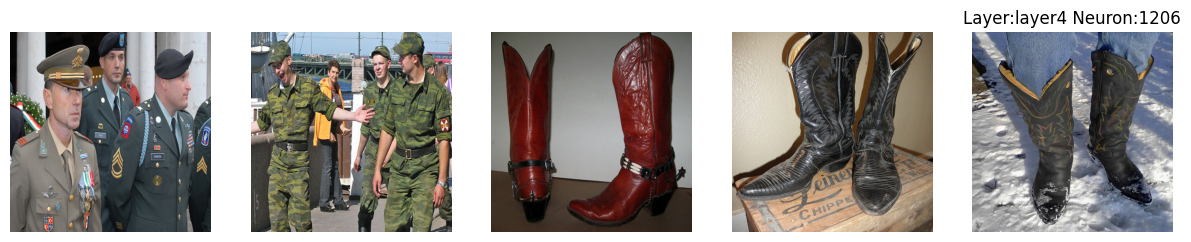


 Layer:layer4 Neuron:1114
1st description: upstairs, sim:0.199
2nd description: downstairs, sim:0.180
3rd description: stair, sim:0.174
5 most highly activating images in D_probe:


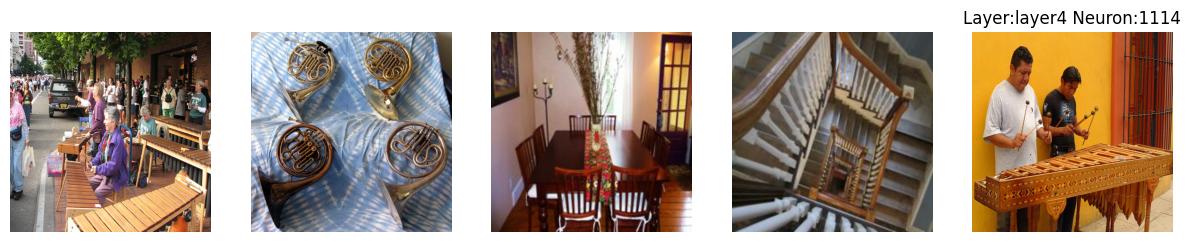

In [5]:
neurons_to_check = ids_to_check = random.sample([i for i in range(target_feats.shape[1])], k=10)
#neurons_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]

ranks = ["1st", "2nd", "3rd"]
top_vals, top_ids = torch.topk(target_feats, k=5, dim=0)

for orig_id in ids_to_check:

    print('\n Layer:{} Neuron:{}'.format(target_layer, (int(orig_id))))
    vals, ids = torch.topk(similarities[orig_id], k=3, largest=True)
    for i in range(len(vals)):
        print("{} description: {}, sim:{:.3f}".format(ranks[i], words[int(ids[i])], vals[i]))
    
    print("5 most highly activating images in D_probe:")
    fig = plt.figure(figsize=(15, 7))
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        fig.add_subplot(1, 5, i+1)
        plt.imshow(im)
        plt.axis('off')
        
    plt.title('Layer:{} Neuron:{}'.format(target_layer, (int(orig_id))))
    plt.show()

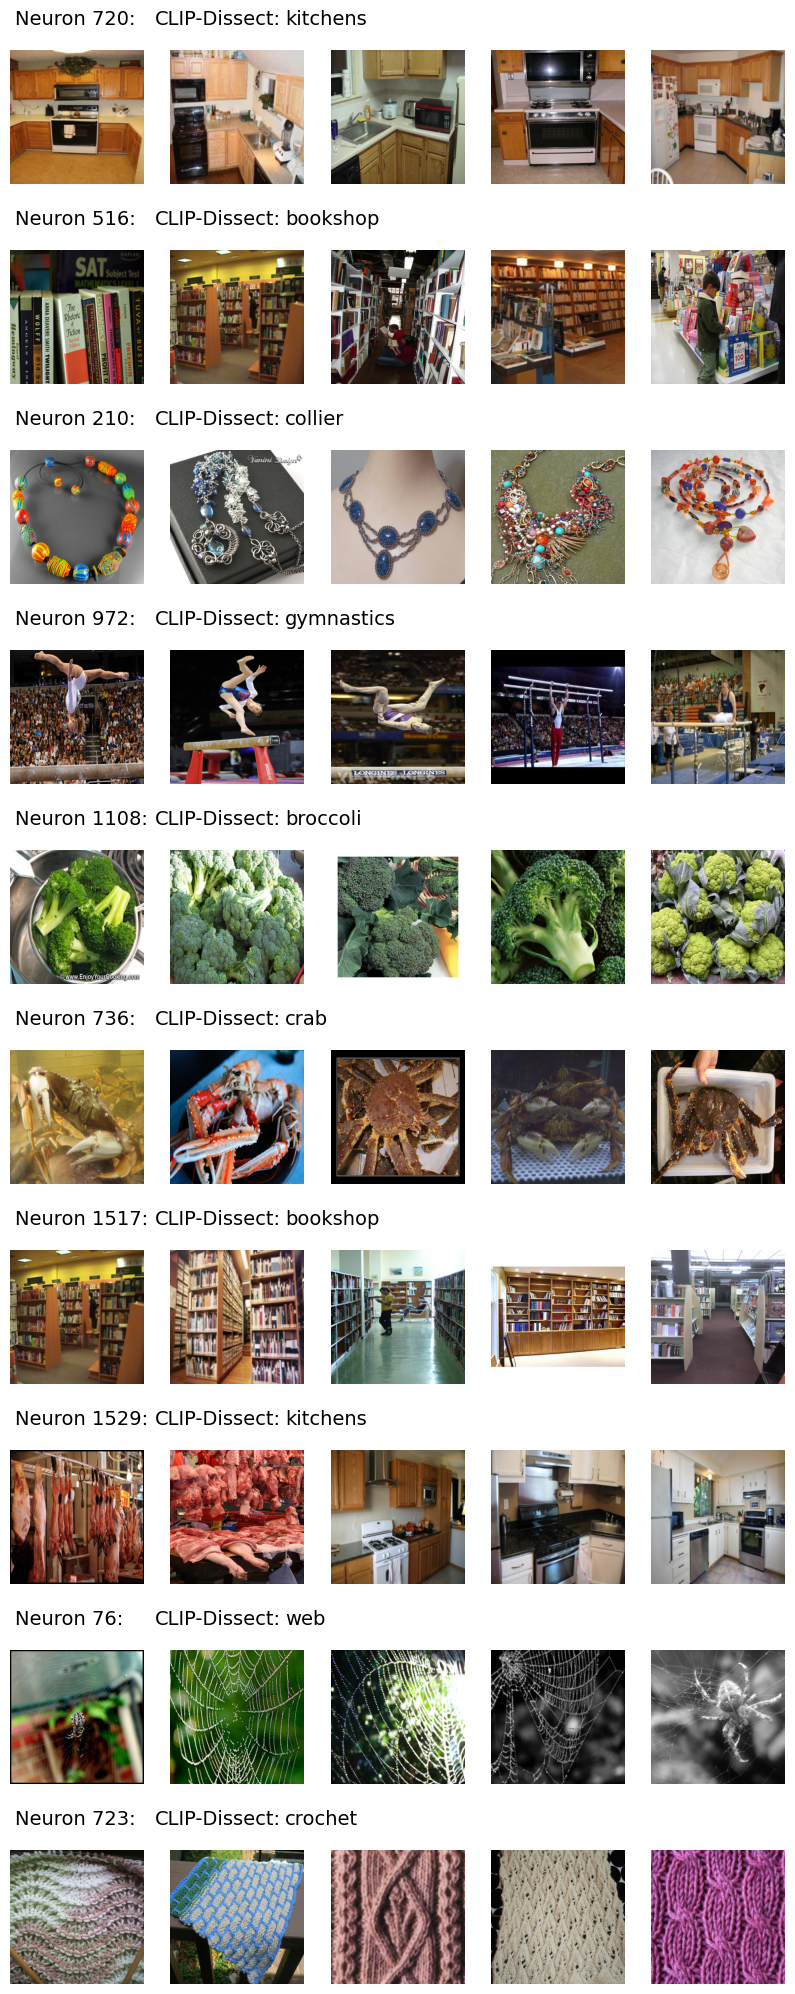

In [6]:
neurons_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]
font_size=14
font = {'size'   : font_size}

matplotlib.rc('font', **font)

fig = plt.figure(figsize=[10, len(neurons_to_check)*2])#constrained_layout=True)
subfigs = fig.subfigures(nrows=len(neurons_to_check), ncols=1)
for j, orig_id in enumerate(neurons_to_check):
    vals, ids = torch.topk(similarities[orig_id], k=5, largest=True)
        
    subfig = subfigs[j]
    subfig.text(0.13, 0.96, "Neuron {}:".format(int(orig_id)), size=font_size)
    subfig.text(0.27, 0.96, "CLIP-Dissect:", size=font_size)
    subfig.text(0.4, 0.96, words[int(ids[0])], size=font_size)
    axs = subfig.subplots(nrows=1, ncols=5)
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        axs[i].imshow(im)
        axs[i].axis('off')
plt.show()